# RFUAV Experiment 4 — Kaggle Version

This notebook trains **ResNet18** on the Kaggle **Noisy Drone RF Signal Classification** dataset.

Before running:

1. Open the notebook on Kaggle.
2. Click **Add Input**.
3. Add the dataset: `sgluege/noisy-drone-rf-signal-classification`.
4. In notebook settings, set **Accelerator → GPU**.

The notebook uses:

```text
/kaggle/input/    # read-only dataset files
/kaggle/working/  # saved models, plots, CSV results
```

The model input is:

```text
x_spec: [number_of_samples, 2, 128, 128]
```


## 1. Check GPU, RAM, and disk

Run this first to confirm whether Kaggle has a GPU attached and enough RAM/disk space.

In [1]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. On Kaggle: Settings → Accelerator → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /kaggle/working


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        27Gi       1.0Mi       3.3Gi        29Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  252K   20G   1% /kaggle/working


## 2. Locate the Kaggle dataset

This replaces the old Colab/Kaggle-API download cells. On Kaggle, use **Add Input** instead of downloading the dataset inside the notebook.

In [2]:
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Find dataset.pt automatically so the notebook still works if Kaggle changes the mounted folder name.
candidates = list(KAGGLE_INPUT.rglob("dataset.pt"))
if not candidates:
    raise FileNotFoundError(
        "Could not find dataset.pt under /kaggle/input. "
        "Click Add Input and attach sgluege/noisy-drone-rf-signal-classification first."
    )

DATA_PATH = candidates[0]
DATA_DIR = DATA_PATH.parent

class_stats_path = DATA_DIR / "class_stats.csv"
snr_stats_path = DATA_DIR / "SNR_stats.csv"

print("DATA_DIR:", DATA_DIR)
print("DATA_PATH:", DATA_PATH)
print("File size GB:", DATA_PATH.stat().st_size / 1024**3)
print("SAVE_DIR:", SAVE_DIR)

print("\nFiles in DATA_DIR:")
for p in sorted(DATA_DIR.iterdir()):
    print("-", p.name)


DATA_DIR: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification
DATA_PATH: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification/dataset.pt
File size GB: 24.099373045377433
SAVE_DIR: /kaggle/working/noisy_drone_resnet18_spec_balanced

Files in DATA_DIR:
- SNR_stats.csv
- class_stats.csv
- dataset.pt


## 3. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [3]:
import pandas as pd

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 4. Safely load `dataset.pt` with memory mapping

`dataset.pt` is large, so normal `torch.load()` can use too much RAM. This notebook uses `mmap=True` to avoid loading everything into memory at once.

In [4]:
import torch

print("Before loading:")
!free -h

data = torch.load(
    DATA_PATH,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


Before loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        26Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        26Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B


## 5. Create a balanced 7-class subset

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1700 training samples per class
- 400 validation samples per class
- 7 classes total

In [5]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

# Set QUICK_TEST = True for a short pipeline test before using GPU quota on a full run.
QUICK_TEST = False

if QUICK_TEST:
    train_per_class = 300
    valid_per_class = 100
else:
    train_per_class = 1700
    valid_per_class = 400

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 11900
Valid samples: 2800
DJI: train=1700, valid=400
FutabaT14: train=1700, valid=400
FutabaT7: train=1700, valid=400
Graupner: train=1700, valid=400
Noise: train=1700, valid=400
Taranis: train=1700, valid=400
Turnigy: train=1700, valid=400


## 6. Build a PyTorch Dataset and DataLoader for `x_spec`

`x_spec` has shape:

```text
[number_of_samples, 2, 128, 128]
```

So the CNN input channel count must be `2`.


In [6]:
from torch.utils.data import Dataset, DataLoader

class NoisyDroneSpecDataset(Dataset):
    def __init__(self, data, indices):
        self.x_spec = data["x_spec"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]   # [2, 128, 128]
        label = self.y[real_idx]
        snr = self.snr[real_idx]
        return x, label, snr

batch_size = 64
num_workers = 0  # Safer for Kaggle + memory-mapped tensors
pin_memory = torch.cuda.is_available()

train_dataset = NoisyDroneSpecDataset(data, train_indices)
valid_dataset = NoisyDroneSpecDataset(data, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch, snr_batch = next(iter(train_loader))
print("x batch:", x_batch.shape)
print("y batch:", y_batch.shape)
print("snr batch:", snr_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("snr dtype:", snr_batch.dtype)


x batch: torch.Size([64, 2, 128, 128])
y batch: torch.Size([64])
snr batch: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
snr dtype: torch.int32


## 7. Define ResNet18 for 2-channel RF spectrograms

Normal ResNet18 expects RGB images with shape:

```text
[batch, 3, height, width]
```

This dataset uses RF spectrogram tensors with shape:

```text
[batch, 2, 128, 128]
```

So we modify the first convolution layer to accept 2 input channels and change the final fully connected layer to output 7 classes.

For this RF dataset, we use `weights=None` because ImageNet pretrained weights are designed for natural RGB images, not 2-channel RF spectrograms.


In [7]:
data = torch.load(
    DATA_PATH,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32


In [8]:
import torch.nn as nn
from torchvision import models

class ResNet18RFSpec(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Start with a standard ResNet18 architecture.
        # weights=None avoids RGB ImageNet pretrained weights.
        self.model = models.resnet18(weights=None)

        # Original ResNet18 first layer expects 3-channel RGB images.
        # Our RF spectrogram tensors have 2 channels, so change 3 -> 2.
        self.model.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Replace the final classifier for 7 drone/noise classes.
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Quick shape test before training.
model_test = ResNet18RFSpec(num_classes=7)
with torch.no_grad():
    out = model_test(x_batch[:2])
print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 8. Set Kaggle output folder for saving results

Kaggle outputs should be saved in `/kaggle/working/` so they appear in the notebook Output section.


In [9]:
SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Save directory:", SAVE_DIR)


Save directory: /kaggle/working/noisy_drone_resnet18_spec_balanced


## 9. Train ResNet18 with learning-rate scheduling

This trains ResNet18 on the balanced spectrogram subset and saves:

- `best.pt`
- `last.pt`
- `history.csv`

This version uses:

- `AdamW` optimizer
- `CosineAnnealingLR` scheduler

Start with `batch_size = 64`. If Kaggle gives a CUDA out-of-memory error, go back to the DataLoader cell and reduce `batch_size` to `32`.

In [10]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd

SPEC_SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler")
SPEC_SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR = SPEC_SAVE_DIR  # keep this name for the existing evaluation cells below

# If True, train only a tiny version to check that the notebook runs.
# Set QUICK_TEST = False in the balanced subset cell for a real 20-epoch run.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Saving spectrogram model to:", SPEC_SAVE_DIR)

model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

epochs = 2 if QUICK_TEST else 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_loader, desc="Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "lr": current_lr,
    })

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), SPEC_SAVE_DIR / "best.pt")
        print("Saved best model.")

torch.save(model.state_dict(), SPEC_SAVE_DIR / "last.pt")

history_df = pd.DataFrame(history)
history_df.to_csv(SPEC_SAVE_DIR / "history.csv", index=False)

print("Finished spectrogram ResNet18 training.")
print("Best valid accuracy:", best_acc)
print("Saved to:", SPEC_SAVE_DIR)


Using device: cuda
Saving spectrogram model to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler
Epoch 1/20


Validation: 100%|██████████| 44/44 [00:06<00:00,  6.31it/s]


Train Loss: 1.4600
Train Acc : 0.4461
Valid Loss: 1.1123
Valid Acc : 0.5996
Learning Rate: 0.000994
Saved best model.
Epoch 2/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 50.70it/s]


Train Loss: 0.8470
Train Acc : 0.6998
Valid Loss: 0.7820
Valid Acc : 0.7300
Learning Rate: 0.000976
Saved best model.
Epoch 3/20


...

Train Loss: 0.0019
Train Acc : 0.9998
Valid Loss: 0.7532
Valid Acc : 0.8575
Learning Rate: 0.000024
Epoch 19/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 49.12it/s]


Train Loss: 0.0015
Train Acc : 0.9999
Valid Loss: 0.8693
Valid Acc : 0.8486
Learning Rate: 0.000006
Epoch 20/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 49.92it/s]

Train Loss: 0.0011
Train Acc : 1.0000
Valid Loss: 0.7999
Valid Acc : 0.8539
Learning Rate: 0.000000
Finished spectrogram ResNet18 training.
Best valid accuracy: 0.8575
Saved to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler


## 10. Plot training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.459964,0.446050,1.112279,0.599643,0.000994
1,2,0.847020,0.699832,0.781997,0.730000,0.000976
2,3,0.621590,0.785378,0.671578,0.778929,0.000946
3,4,0.509422,0.826303,0.654313,0.781429,0.000905
4,5,0.401376,0.862017,0.667499,0.793929,0.000854
5,6,0.346214,0.881765,0.523334,0.832857,0.000794
6,7,0.290485,0.902017,0.488404,0.848214,0.000727
7,8,0.218883,0.923950,0.605919,0.822143,0.000655
8,9,0.165639,0.942521,0.568118,0.840714,0.000578
9,10,0.113148,0.961933,0.669445,0.836786,0.000500


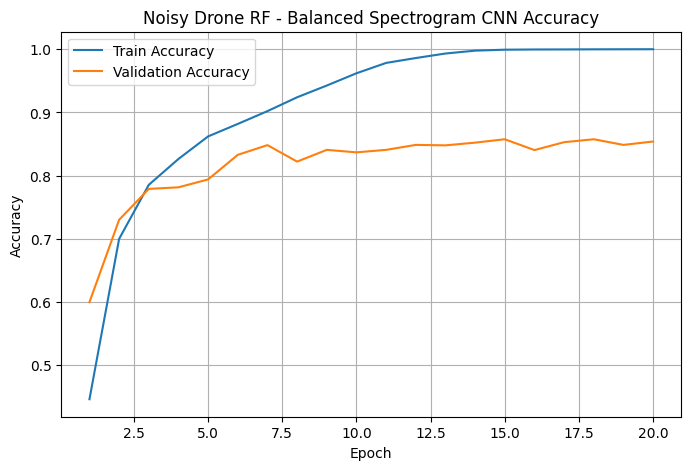

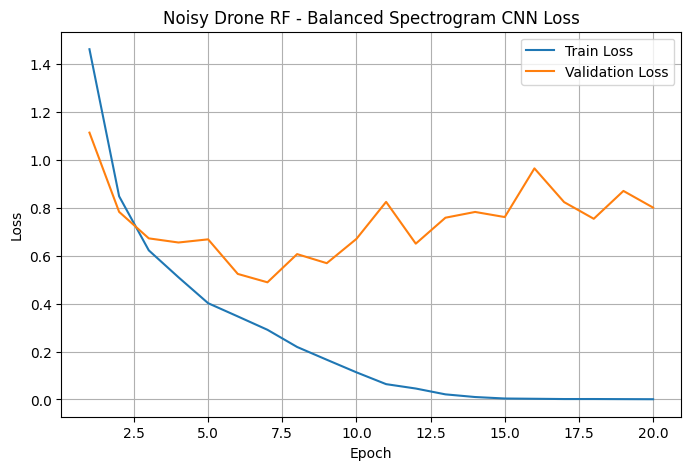

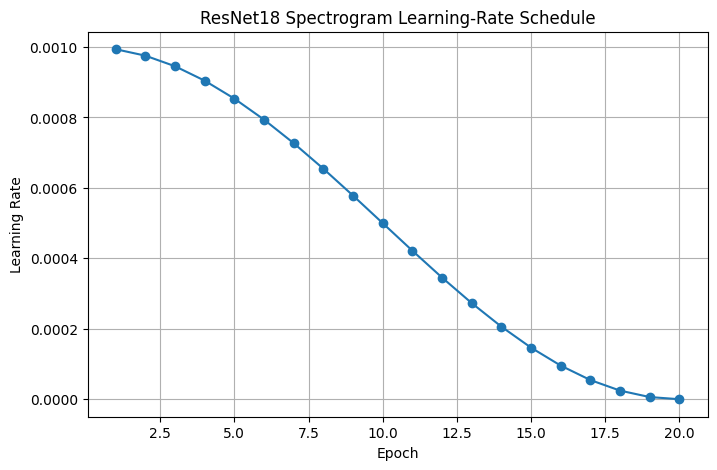

In [11]:
import matplotlib.pyplot as plt

history_path = os.path.join(SAVE_DIR, "history.csv")
history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

if "lr" in history_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["lr"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("ResNet18 Spectrogram Learning-Rate Schedule")
    plt.grid(True)
    plt.show()


## 11. Classification report and confusion matrix

Use macro F1 because this dataset is naturally imbalanced, even though this first subset is balanced.


Loaded best model: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/best.pt
              precision    recall  f1-score   support

         DJI       0.88      0.89      0.88       400
   FutabaT14       0.92      0.82      0.87       400
    FutabaT7       0.86      0.83      0.85       400
    Graupner       0.95      0.90      0.92       400
       Noise       0.67      0.82      0.73       400
     Taranis       0.96      0.92      0.94       400
     Turnigy       0.82      0.82      0.82       400

    accuracy                           0.86      2800
   macro avg       0.87      0.86      0.86      2800
weighted avg       0.87      0.86      0.86      2800



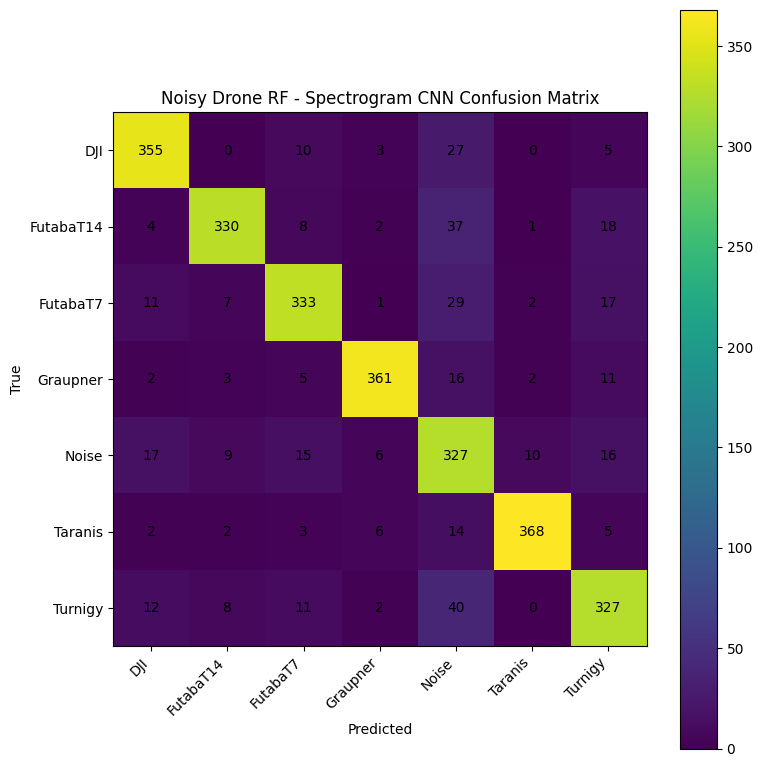

Saved confusion matrix to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix.png


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model before evaluation
best_path = os.path.join(SAVE_DIR, "best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_snrs.extend(snrs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Spectrogram CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print("Saved confusion matrix to:", cm_path)


## 12. Accuracy by SNR

This is one of the most important analyses for this dataset.

Low SNR values like `-20 dB` should be harder. High SNR values like `20 dB` to `30 dB` should be easier.


,SNR,accuracy
0,-20,0.168224
1,-18,0.404255
2,-16,0.504854
3,-14,0.626984
4,-12,0.754902
5,-10,0.813953
6,-8,0.875000
7,-6,0.911765
8,-4,0.897959
9,-2,0.942623


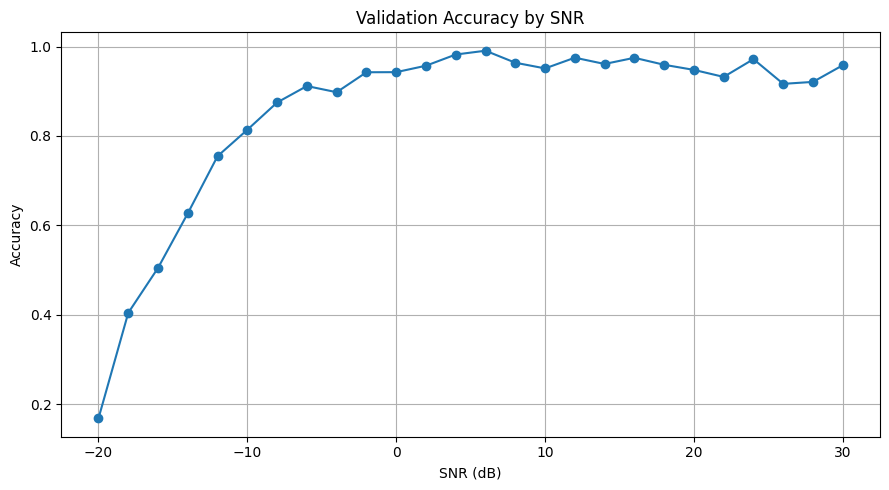

Saved SNR accuracy plot to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/accuracy_by_snr.png


In [13]:
results_df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "snr": all_snrs,
})
results_df["correct"] = results_df["label"] == results_df["pred"]

snr_acc = results_df.groupby("snr")["correct"].mean().reset_index()
snr_acc.columns = ["SNR", "accuracy"]
display(snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_acc["SNR"], snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_path = os.path.join(SAVE_DIR, "accuracy_by_snr.png")
plt.savefig(snr_path, dpi=200)
plt.show()
print("Saved SNR accuracy plot to:", snr_path)


## 13. Confusion matrices by SNR group

The overall confusion matrix hides where the model fails. This section splits the validation set into low, medium, and high SNR groups, then creates a separate confusion matrix for each group.

Suggested groups:

```text
Low SNR:    -20 to -10 dB
Medium SNR: -8 to 4 dB
High SNR:    6 to 30 dB
```

This helps show whether errors such as `Turnigy → Noise` mainly happen when the RF signal is weak.


low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.5405

Classification report:
              precision    recall  f1-score   support

         DJI       0.59      0.52      0.55        81
   FutabaT14       0.64      0.28      0.39        88
    FutabaT7       0.57      0.40      0.47        88
    Graupner       0.81      0.59      0.68        87
       Noise       0.33      0.84      0.47        87
     Taranis       0.89      0.66      0.76        86
     Turnigy       0.52      0.50      0.51       101

    accuracy                           0.54       618
   macro avg       0.62      0.54      0.55       618
weighted avg       0.62      0.54      0.55       618



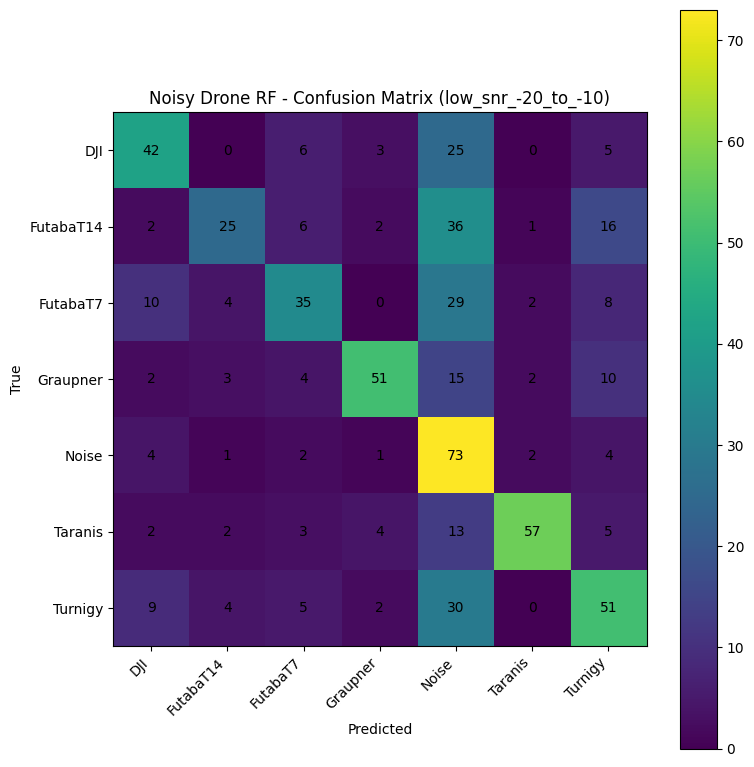

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix_low_snr_-20_to_-10.png
medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.9317

Classification report:
              precision    recall  f1-score   support

         DJI       0.92      0.97      0.94       112
   FutabaT14       0.93      0.95      0.94       112
    FutabaT7       0.90      0.92      0.91       106
    Graupner       0.98      0.99      0.99       119
       Noise       0.90      0.85      0.87       104
     Taranis       0.97      0.98      0.98       111
     Turnigy       0.91      0.84      0.87        97

    accuracy                           0.93       761
   macro avg       0.93      0.93      0.93       761
weighted avg       0.93      0.93      0.93       761



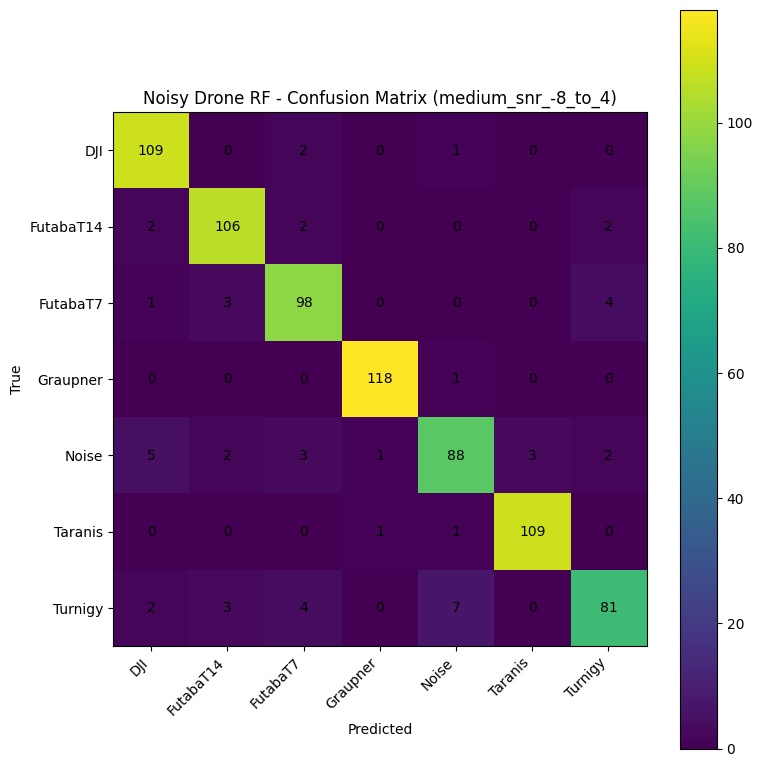

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix_medium_snr_-8_to_4.png
high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9557

Classification report:
              precision    recall  f1-score   support

         DJI       0.96      0.99      0.97       207
   FutabaT14       0.97      0.99      0.98       200
    FutabaT7       0.93      0.97      0.95       206
    Graupner       0.97      0.99      0.98       194
       Noise       0.97      0.79      0.87       209
     Taranis       0.98      1.00      0.99       203
     Turnigy       0.92      0.97      0.94       202

    accuracy                           0.96      1421
   macro avg       0.96      0.96      0.95      1421
weighted avg       0.96      0.96      0.95      1421



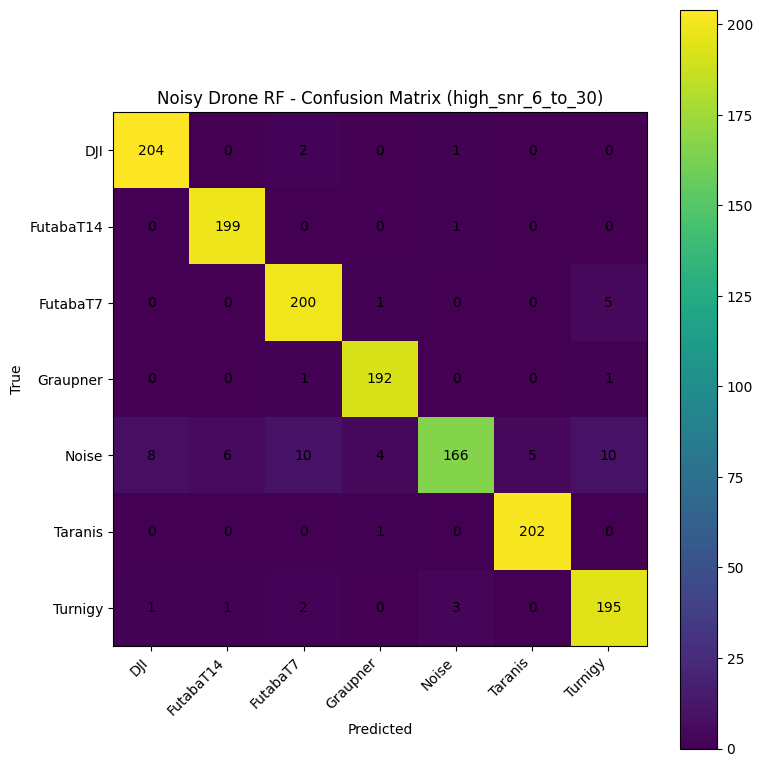

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix_high_snr_6_to_30.png


,group,snr_min,snr_max,samples,accuracy
0,low_snr_-20_to_-10,-20,-10,618,0.540453
1,medium_snr_-8_to_4,-8,4,761,0.931669
2,high_snr_6_to_30,6,30,1421,0.955665


Saved SNR group summary to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/snr_group_summary.csv


In [14]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# This cell expects these variables from the evaluation cell:
# all_labels, all_preds, all_snrs, class_names, SAVE_DIR

results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})

results_df["correct"] = results_df["label"] == results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

def plot_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    return cm

snr_summary_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    if len(subset) == 0:
        print(f"No validation samples found for {group_name}")
        continue

    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"{group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification report:")
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR, f"confusion_matrix_{group_name}.png")
    cm_group = plot_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - Confusion Matrix ({group_name})",
        save_path
    )
    print("Saved:", save_path)

    snr_summary_rows.append({
        "group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "samples": len(subset),
        "accuracy": acc,
    })

snr_group_summary = pd.DataFrame(snr_summary_rows)
display(snr_group_summary)

summary_path = os.path.join(SAVE_DIR, "snr_group_summary.csv")
snr_group_summary.to_csv(summary_path, index=False)
print("Saved SNR group summary to:", summary_path)


---

# 14. IQ-based model experiment

The previous experiment used `x_spec`, a 2-channel spectrogram tensor.

This section uses the raw I/Q tensor directly:

```text
x_iq: [number_of_samples, 2, 16384]
```

The model is a 1D CNN with `Conv1d(2, ...)`, because the two channels represent I and Q. This experiment also uses `AdamW` and `CosineAnnealingLR`.


## 14.1 Build Dataset and DataLoaders for `x_iq`

Each sample is normalized independently. This helps the 1D CNN focus on waveform shape instead of absolute amplitude scale.


In [15]:
class NoisyDroneIQDataset(Dataset):
    def __init__(self, data, indices, normalize=True):
        self.x_iq = data["x_iq"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices
        self.normalize = normalize

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])

        x = self.x_iq[real_idx]   # [2, 16384]
        label = self.y[real_idx]
        snr = self.snr[real_idx]

        if self.normalize:
            x = (x - x.mean()) / (x.std() + 1e-8)

        return x, label, snr

# Raw IQ sequences are larger than spectrogram tensors, so reduce this if GPU memory is tight.
iq_batch_size = 64

train_iq_dataset = NoisyDroneIQDataset(data, train_indices, normalize=True)
valid_iq_dataset = NoisyDroneIQDataset(data, valid_indices, normalize=True)

train_iq_loader = DataLoader(
    train_iq_dataset,
    batch_size=iq_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_iq_loader = DataLoader(
    valid_iq_dataset,
    batch_size=iq_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_iq_batch, y_iq_batch, snr_iq_batch = next(iter(train_iq_loader))

print("IQ batch:", x_iq_batch.shape)
print("Label batch:", y_iq_batch.shape)
print("SNR batch:", snr_iq_batch.shape)
print("IQ dtype:", x_iq_batch.dtype)


IQ batch: torch.Size([64, 2, 16384])
Label batch: torch.Size([64])
SNR batch: torch.Size([64])
IQ dtype: torch.float32


## 14.2 Define IQ 1D CNN

This model learns directly from the I/Q time sequence instead of the spectrogram image.


In [16]:
class IQ1DCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Quick shape test before training.
model_test = IQ1DCNN(num_classes=len(class_names))
with torch.no_grad():
    out = model_test(x_iq_batch[:2])

print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 14.3 Train IQ 1D CNN with learning-rate scheduling

This uses the same balanced indices as the spectrogram experiment, so the two results are comparable.


In [17]:
IQ_SAVE_DIR = Path("/kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler")
IQ_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print("Saving IQ model to:", IQ_SAVE_DIR)

model_iq = IQ1DCNN(num_classes=len(class_names)).to(device)
criterion_iq = nn.CrossEntropyLoss()

optimizer_iq = optim.AdamW(
    model_iq.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

iq_epochs = 2 if QUICK_TEST else 20
scheduler_iq = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_iq,
    T_max=iq_epochs
)

history_iq = []
best_iq_acc = 0.0

for epoch in range(iq_epochs):
    print("=" * 60)
    print(f"IQ Epoch {epoch + 1}/{iq_epochs}")

    model_iq.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_iq_loader, desc="IQ Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_iq.zero_grad()
        outputs = model_iq(x)
        loss = criterion_iq(outputs, labels)
        loss.backward()
        optimizer_iq.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model_iq.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_iq_loader, desc="IQ Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_iq(x)
            loss = criterion_iq(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    scheduler_iq.step()
    current_lr = optimizer_iq.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    history_iq.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "lr": current_lr,
    })

    if valid_acc > best_iq_acc:
        best_iq_acc = valid_acc
        torch.save(model_iq.state_dict(), IQ_SAVE_DIR / "best.pt")
        print("Saved best IQ model.")

torch.save(model_iq.state_dict(), IQ_SAVE_DIR / "last.pt")

history_iq_df = pd.DataFrame(history_iq)
history_iq_df.to_csv(IQ_SAVE_DIR / "history.csv", index=False)

print("Finished IQ 1D CNN training.")
print("Best IQ valid accuracy:", best_iq_acc)
print("Saved to:", IQ_SAVE_DIR)


Using device: cuda
Saving IQ model to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler
IQ Epoch 1/20


IQ Validation: 100%|██████████| 44/44 [00:07<00:00,  5.67it/s]


Train Loss: 1.3163
Train Acc : 0.5171
Valid Loss: 2.2029
Valid Acc : 0.4000
Learning Rate: 0.000994
Saved best IQ model.
IQ Epoch 2/20


IQ Validation: 100%|██████████| 44/44 [00:00<00:00, 45.25it/s]


Train Loss: 1.0106
Train Acc : 0.6406
Valid Loss: 1.6216
Valid Acc : 0.4743
Learning Rate: 0.000976
Saved best IQ model.
IQ Epoch 3/20


...

Train Loss: 0.2101
Train Acc : 0.9508
Valid Loss: 0.8616
Valid Acc : 0.7029
Learning Rate: 0.000024
IQ Epoch 19/20


IQ Validation: 100%|██████████| 44/44 [00:00<00:00, 49.08it/s]


Train Loss: 0.2010
Train Acc : 0.9529
Valid Loss: 0.8052
Valid Acc : 0.7311
Learning Rate: 0.000006
IQ Epoch 20/20


IQ Validation: 100%|██████████| 44/44 [00:00<00:00, 48.88it/s]

Train Loss: 0.1945
Train Acc : 0.9560
Valid Loss: 0.7935
Valid Acc : 0.7404
Learning Rate: 0.000000
Saved best IQ model.
Finished IQ 1D CNN training.
Best IQ valid accuracy: 0.7403571428571428
Saved to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler


## 14.4 Plot IQ training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.316332,0.517059,2.202874,0.400000,0.000994
1,2,1.010646,0.640588,1.621643,0.474286,0.000976
2,3,0.907622,0.681765,2.384243,0.465357,0.000946
3,4,0.840365,0.703950,1.217522,0.633929,0.000905
4,5,0.818227,0.710840,3.385563,0.491429,0.000854
5,6,0.747088,0.736555,2.867682,0.488214,0.000794
6,7,0.710427,0.747143,1.515679,0.583214,0.000727
7,8,0.655292,0.771513,2.037989,0.562857,0.000655
8,9,0.595657,0.793361,2.104024,0.624286,0.000578
9,10,0.544011,0.817143,2.696745,0.557500,0.000500


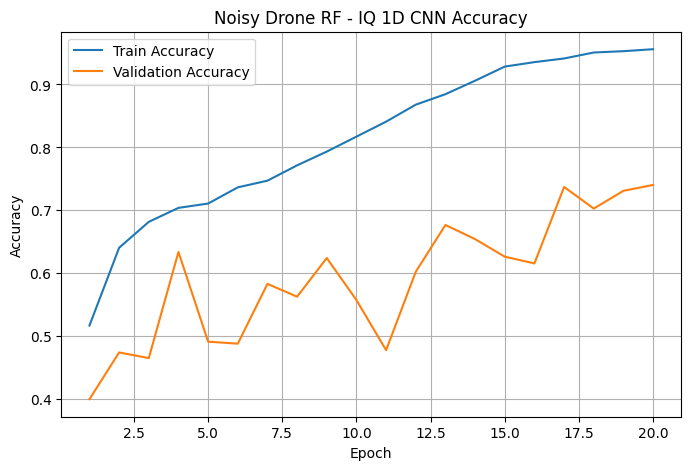

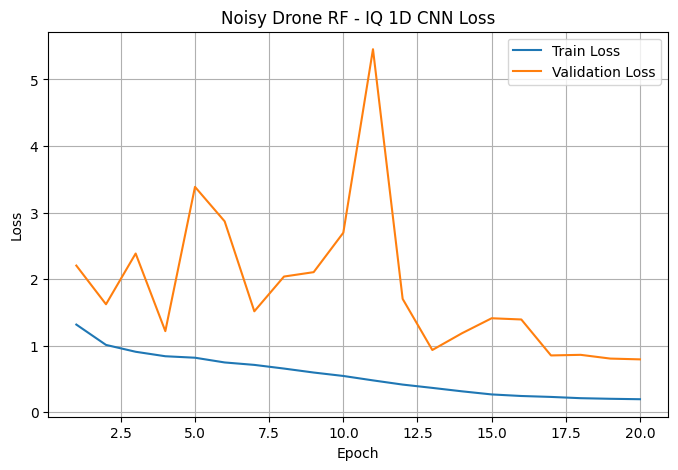

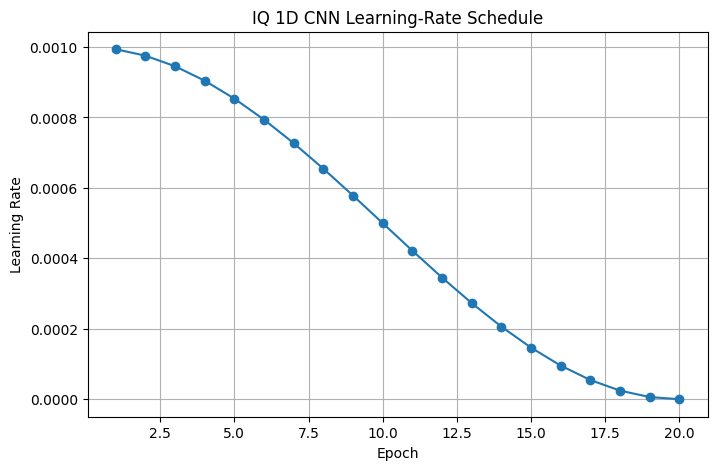

In [18]:
history_iq_path = IQ_SAVE_DIR / "history.csv"
history_iq_df = pd.read_csv(history_iq_path)
display(history_iq_df)

plt.figure(figsize=(8, 5))
plt.plot(history_iq_df["epoch"], history_iq_df["train_acc"], label="Train Accuracy")
plt.plot(history_iq_df["epoch"], history_iq_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - IQ 1D CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_iq_df["epoch"], history_iq_df["train_loss"], label="Train Loss")
plt.plot(history_iq_df["epoch"], history_iq_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - IQ 1D CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_iq_df["epoch"], history_iq_df["lr"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("IQ 1D CNN Learning-Rate Schedule")
plt.grid(True)
plt.show()


## 14.5 Evaluate IQ 1D CNN

This creates the same outputs as the spectrogram experiment: classification report, confusion matrix, and saved prediction table.


Loaded best IQ model: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/best.pt
              precision    recall  f1-score   support

         DJI       0.83      0.75      0.79       400
   FutabaT14       0.77      0.73      0.75       400
    FutabaT7       0.78      0.70      0.74       400
    Graupner       0.86      0.80      0.83       400
       Noise       0.43      0.72      0.54       400
     Taranis       0.95      0.82      0.88       400
     Turnigy       0.83      0.65      0.73       400

    accuracy                           0.74      2800
   macro avg       0.78      0.74      0.75      2800
weighted avg       0.78      0.74      0.75      2800



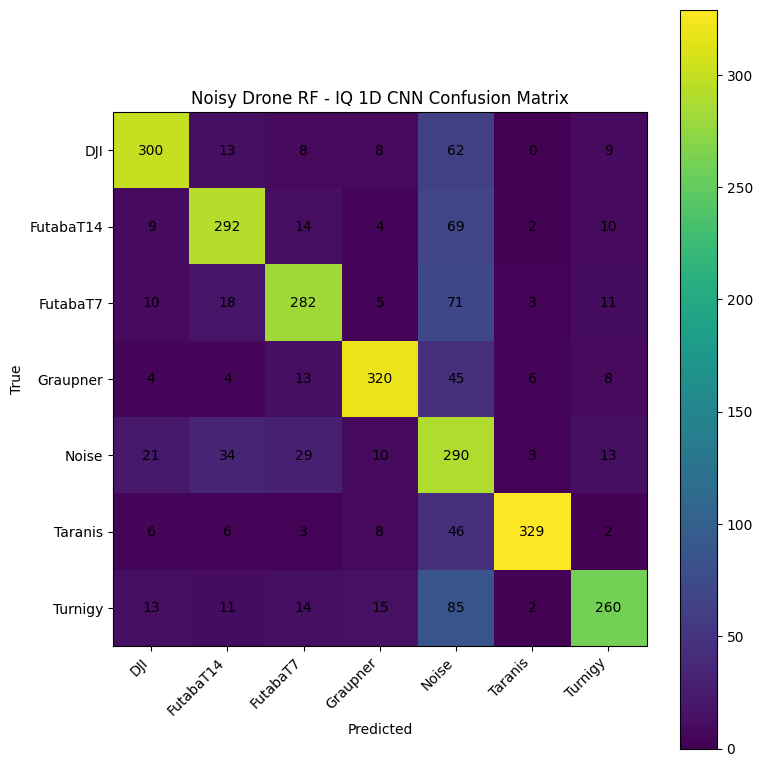

Saved IQ confusion matrix to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_1dcnn.png
Saved IQ prediction table to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/valid_predictions.csv


In [19]:
# Load best IQ model before evaluation.
best_iq_path = IQ_SAVE_DIR / "best.pt"
if best_iq_path.exists():
    model_iq.load_state_dict(torch.load(best_iq_path, map_location=device))
    print("Loaded best IQ model:", best_iq_path)

model_iq.eval()
all_iq_preds = []
all_iq_labels = []
all_iq_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_iq_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_iq(x)
        preds = outputs.argmax(dim=1)

        all_iq_preds.extend(preds.cpu().numpy())
        all_iq_labels.extend(labels.cpu().numpy())
        all_iq_snrs.extend(snrs.cpu().numpy())

print(classification_report(
    all_iq_labels,
    all_iq_preds,
    target_names=class_names
))

cm_iq = confusion_matrix(all_iq_labels, all_iq_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm_iq)
plt.title("Noisy Drone RF - IQ 1D CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_iq[i, j], ha="center", va="center")

plt.tight_layout()
cm_iq_path = IQ_SAVE_DIR / "confusion_matrix_iq_1dcnn.png"
plt.savefig(cm_iq_path, dpi=200)
plt.show()

print("Saved IQ confusion matrix to:", cm_iq_path)

results_iq_df = pd.DataFrame({
    "label": all_iq_labels,
    "pred": all_iq_preds,
    "snr": all_iq_snrs,
})
results_iq_df["correct"] = results_iq_df["label"] == results_iq_df["pred"]
results_iq_df.to_csv(IQ_SAVE_DIR / "valid_predictions.csv", index=False)
print("Saved IQ prediction table to:", IQ_SAVE_DIR / "valid_predictions.csv")


## 14.6 IQ accuracy by SNR


,SNR,accuracy
0,-20,0.102804
1,-18,0.191489
2,-16,0.252427
3,-14,0.277778
4,-12,0.303922
5,-10,0.383721
6,-8,0.519231
7,-6,0.607843
8,-4,0.663265
9,-2,0.762295


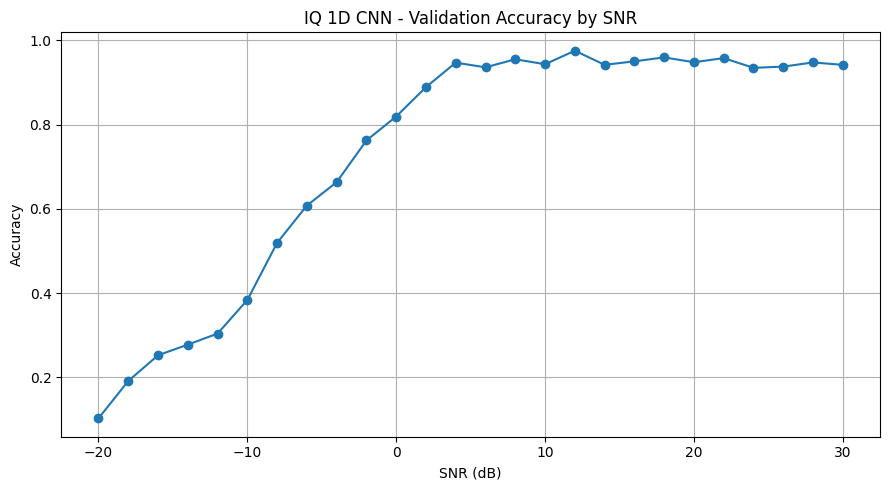

Saved IQ SNR accuracy plot to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/accuracy_by_snr_iq_1dcnn.png


In [20]:
snr_iq_acc = results_iq_df.groupby("snr")["correct"].mean().reset_index()
snr_iq_acc.columns = ["SNR", "accuracy"]
display(snr_iq_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_iq_acc["SNR"], snr_iq_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("IQ 1D CNN - Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_iq_path = IQ_SAVE_DIR / "accuracy_by_snr_iq_1dcnn.png"
plt.savefig(snr_iq_path, dpi=200)
plt.show()

print("Saved IQ SNR accuracy plot to:", snr_iq_path)


## 14.7 IQ confusion matrices by SNR group

This lets you compare whether the IQ model handles low-SNR samples better or worse than the spectrogram ResNet18 model.


low_snr_-20_to_-10
Samples: 618
Accuracy: 0.24919093851132687
              precision    recall  f1-score   support

         DJI       0.23      0.15      0.18        81
   FutabaT14       0.19      0.11      0.14        88
    FutabaT7       0.14      0.07      0.09        88
    Graupner       0.49      0.29      0.36        87
       Noise       0.19      0.76      0.30        87
     Taranis       0.83      0.29      0.43        86
     Turnigy       0.26      0.10      0.14       101

    accuracy                           0.25       618
   macro avg       0.33      0.25      0.24       618
weighted avg       0.33      0.25      0.23       618



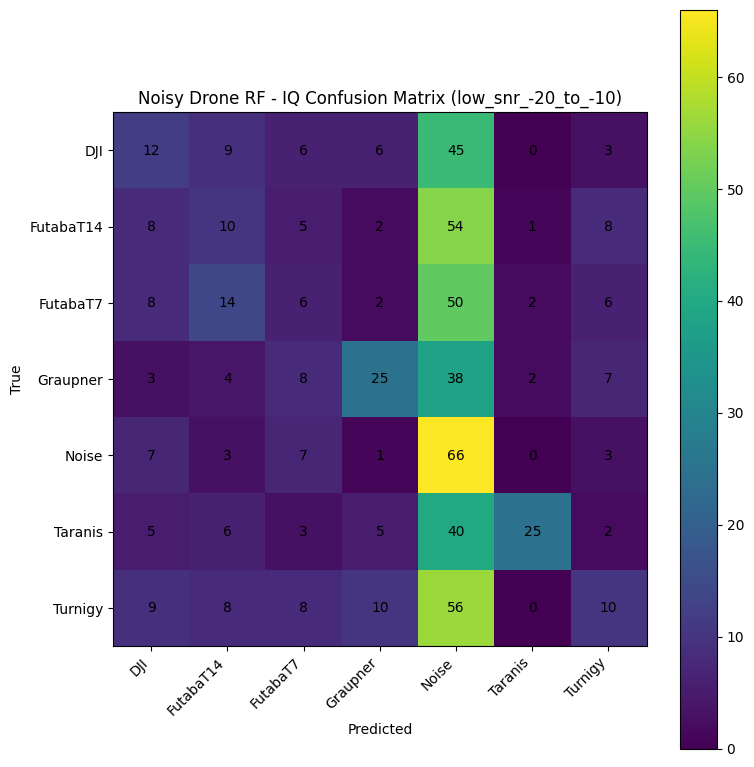

Saved: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_low_snr_-20_to_-10.png
medium_snr_-8_to_4
Samples: 761
Accuracy: 0.7503285151116952
              precision    recall  f1-score   support

         DJI       0.83      0.77      0.80       112
   FutabaT14       0.79      0.76      0.78       112
    FutabaT7       0.75      0.69      0.72       106
    Graupner       0.87      0.86      0.86       119
       Noise       0.44      0.67      0.53       104
     Taranis       0.91      0.92      0.91       111
     Turnigy       0.79      0.55      0.65        97

    accuracy                           0.75       761
   macro avg       0.77      0.74      0.75       761
weighted avg       0.78      0.75      0.76       761



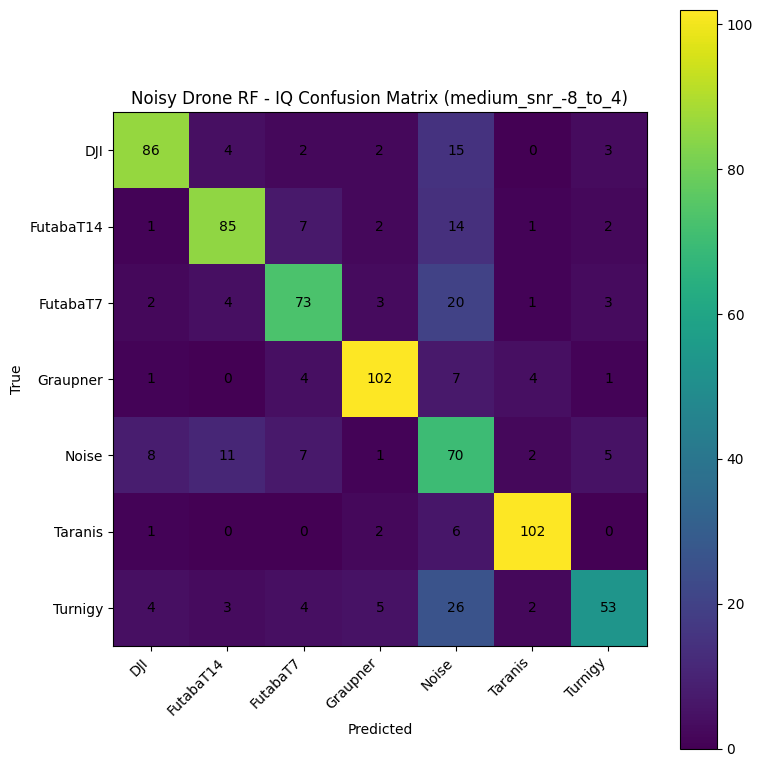

Saved: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_medium_snr_-8_to_4.png
high_snr_6_to_30
Samples: 1421
Accuracy: 0.9486277269528501
              precision    recall  f1-score   support

         DJI       0.97      0.98      0.97       207
   FutabaT14       0.91      0.98      0.94       200
    FutabaT7       0.91      0.99      0.95       206
    Graupner       0.96      0.99      0.97       194
       Noise       0.96      0.74      0.83       209
     Taranis       1.00      1.00      1.00       203
     Turnigy       0.95      0.98      0.96       202

    accuracy                           0.95      1421
   macro avg       0.95      0.95      0.95      1421
weighted avg       0.95      0.95      0.95      1421



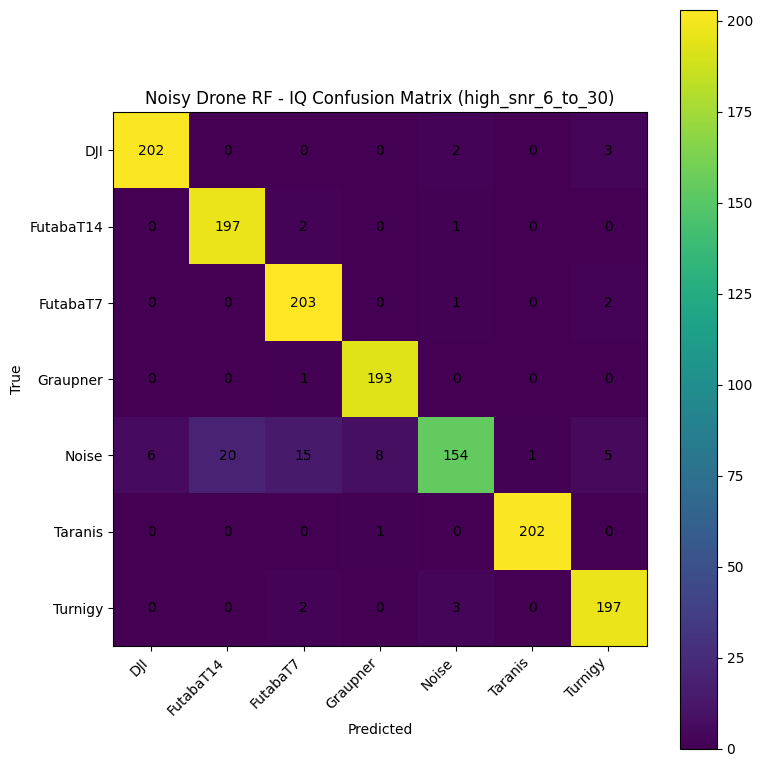

Saved: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_high_snr_6_to_30.png


In [21]:
def plot_iq_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved:", save_path)
    return cm

for group_name, (low, high) in snr_groups.items():
    subset = results_iq_df[(results_iq_df["snr"] >= low) & (results_iq_df["snr"] <= high)]

    print("=" * 60)
    print(group_name)
    print("Samples:", len(subset))

    if len(subset) == 0:
        print("No samples in this SNR group.")
        continue

    print("Accuracy:", subset["correct"].mean())
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    ))

    save_path = IQ_SAVE_DIR / f"confusion_matrix_iq_{group_name}.png"
    plot_iq_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - IQ Confusion Matrix ({group_name})",
        save_path
    )


---

# 15. Compare spectrogram ResNet18 vs IQ 1D CNN

Use this section after both models have finished training and evaluation. The most important comparison is not only overall validation accuracy, but also low-SNR behavior.


In [22]:
comparison_rows = []

# Spectrogram model metrics from results_df
if "results_df" in globals():
    comparison_rows.append({
        "model": "ResNet18 on x_spec",
        "overall_accuracy": results_df["correct"].mean(),
        "low_snr_accuracy": results_df[(results_df["snr"] >= -20) & (results_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_df[(results_df["snr"] >= -8) & (results_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_df[(results_df["snr"] >= 6) & (results_df["snr"] <= 30)]["correct"].mean(),
    })

# IQ model metrics from results_iq_df
if "results_iq_df" in globals():
    comparison_rows.append({
        "model": "1D CNN on x_iq",
        "overall_accuracy": results_iq_df["correct"].mean(),
        "low_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= -20) & (results_iq_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= -8) & (results_iq_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= 6) & (results_iq_df["snr"] <= 30)]["correct"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
comparison_df.to_csv(Path("/kaggle/working/model_comparison_spec_vs_iq.csv"), index=False)
print("Saved comparison table to /kaggle/working/model_comparison_spec_vs_iq.csv")


,model,overall_accuracy,low_snr_accuracy,medium_snr_accuracy,high_snr_accuracy
0,ResNet18 on x_spec,0.857500,0.540453,0.931669,0.955665
1,1D CNN on x_iq,0.740357,0.249191,0.750329,0.948628


Saved comparison table to /kaggle/working/model_comparison_spec_vs_iq.csv


---

# 16. Fusion experiment: Spectrogram ResNet18 + FFT-from-IQ branch

This experiment combines the two representations already present in the dataset:

- `x_spec`: 2-channel spectrogram tensor, processed by a ResNet18 feature branch.
- `x_iq`: raw I/Q waveform, converted to FFT magnitude inside the model and processed by a 1D CNN branch.

The two feature vectors are concatenated and passed into a final classifier.

The goal is to test whether combining a time-frequency spectrogram view with an IQ-derived frequency-domain view improves robustness, especially at low SNR.

## 16.1 Build fusion Dataset and DataLoaders

This dataset returns both `x_spec` and `x_iq` for the same sample index. The model will receive both inputs at once.

The data is normalized per sample to reduce scale differences between examples.

In [23]:
class NoisyDroneFusionDataset(Dataset):
    def __init__(self, data, indices, normalize_spec=True, normalize_iq=True):
        self.x_spec = data["x_spec"]
        self.x_iq = data["x_iq"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices
        self.normalize_spec = normalize_spec
        self.normalize_iq = normalize_iq

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])

        x_spec = self.x_spec[real_idx]   # [2, 128, 128]
        x_iq = self.x_iq[real_idx]       # [2, 16384]
        label = self.y[real_idx]
        snr = self.snr[real_idx]

        if self.normalize_spec:
            x_spec = (x_spec - x_spec.mean()) / (x_spec.std() + 1e-8)

        if self.normalize_iq:
            x_iq = (x_iq - x_iq.mean()) / (x_iq.std() + 1e-8)

        return x_spec, x_iq, label, snr

# Fusion uses both x_spec and x_iq, so reduce batch size if GPU memory is tight.
fusion_batch_size = 32 if not QUICK_TEST else 16

train_fusion_dataset = NoisyDroneFusionDataset(data, train_indices)
valid_fusion_dataset = NoisyDroneFusionDataset(data, valid_indices)

train_fusion_loader = DataLoader(
    train_fusion_dataset,
    batch_size=fusion_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_fusion_loader = DataLoader(
    valid_fusion_dataset,
    batch_size=fusion_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_spec_batch, x_iq_batch, y_fusion_batch, snr_fusion_batch = next(iter(train_fusion_loader))

print("x_spec batch:", x_spec_batch.shape)
print("x_iq batch:", x_iq_batch.shape)
print("label batch:", y_fusion_batch.shape)
print("snr batch:", snr_fusion_batch.shape)
print("fusion batch size:", fusion_batch_size)

x_spec batch: torch.Size([32, 2, 128, 128])
x_iq batch: torch.Size([32, 2, 16384])
label batch: torch.Size([32])
snr batch: torch.Size([32])
fusion batch size: 32


## 16.2 Define fusion model

Architecture:

```text
x_spec [B, 2, 128, 128]
    -> ResNet18 feature branch
    -> 256-dim spectrogram feature

x_iq [B, 2, 16384]
    -> complex I + jQ
    -> FFT magnitude
    -> 1D CNN feature branch
    -> 256-dim FFT feature

concat [B, 512]
    -> classifier
    -> 7 classes
```

The ResNet branch uses a smaller first convolution (`3x3`, stride `1`) and removes the initial maxpool. This preserves more detail for 128x128 RF spectrograms.

In [24]:
class SpecFFTFusionNet(nn.Module):
    def __init__(self, num_classes=7, fft_bins=2048):
        super().__init__()
        self.fft_bins = fft_bins

        # -----------------------------
        # Spectrogram branch: ResNet18
        # -----------------------------
        resnet = models.resnet18(weights=None)

        # RF spectrogram has 2 channels, not RGB.
        # Use 3x3 stride-1 conv for 128x128 inputs.
        resnet.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        resnet.maxpool = nn.Identity()
        resnet.fc = nn.Identity()
        self.spec_branch = resnet

        self.spec_projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # -----------------------------
        # FFT branch from raw IQ
        # -----------------------------
        self.fft_branch = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.fft_projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # -----------------------------
        # Fusion classifier
        # -----------------------------
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def iq_to_fft_mag(self, x_iq):
        """
        Convert raw IQ to log FFT magnitude.

        x_iq: [batch, 2, 16384]
              channel 0 = I, channel 1 = Q

        returns: [batch, 1, fft_bins]
        """
        i = x_iq[:, 0, :]
        q = x_iq[:, 1, :]
        x_complex = torch.complex(i, q)

        # Use the first fft_bins samples to reduce compute.
        x_complex = x_complex[:, :self.fft_bins]

        window = torch.hann_window(self.fft_bins, device=x_iq.device).unsqueeze(0)
        x_complex = x_complex * window

        spectrum = torch.fft.fft(x_complex, dim=-1)
        spectrum = torch.fft.fftshift(spectrum, dim=-1)

        mag = torch.abs(spectrum)
        mag = torch.log1p(mag)

        # Normalize each FFT vector independently.
        mag = (mag - mag.mean(dim=-1, keepdim=True)) / (mag.std(dim=-1, keepdim=True) + 1e-8)

        return mag.unsqueeze(1)

    def forward(self, x_spec, x_iq):
        spec_features = self.spec_branch(x_spec)              # [B, 512]
        spec_features = self.spec_projector(spec_features)    # [B, 256]

        fft_mag = self.iq_to_fft_mag(x_iq)                    # [B, 1, fft_bins]
        fft_features = self.fft_branch(fft_mag)               # [B, 128, 1]
        fft_features = self.fft_projector(fft_features)       # [B, 256]

        fused = torch.cat([spec_features, fft_features], dim=1) # [B, 512]
        return self.classifier(fused)

# Quick shape test before training.
fusion_model_test = SpecFFTFusionNet(num_classes=len(class_names), fft_bins=2048)
with torch.no_grad():
    test_out = fusion_model_test(x_spec_batch[:2], x_iq_batch[:2])

print("Fusion test output shape:", test_out.shape)

Fusion test output shape: torch.Size([2, 7])


## 16.3 Train fusion model with learning-rate scheduling

This uses `AdamW` and `CosineAnnealingLR`, matching the previous ResNet and IQ experiments.

The model saves:

- `best.pt`
- `last.pt`
- `history.csv`

In [25]:
FUSION_SAVE_DIR = Path("/kaggle/working/noisy_drone_fusion_spec_fft")
FUSION_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print("Saving fusion model to:", FUSION_SAVE_DIR)

model_fusion = SpecFFTFusionNet(num_classes=len(class_names), fft_bins=2048).to(device)
criterion_fusion = nn.CrossEntropyLoss()

optimizer_fusion = optim.AdamW(
    model_fusion.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

fusion_epochs = 2 if QUICK_TEST else 20
scheduler_fusion = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fusion,
    T_max=fusion_epochs
)

history_fusion = []
best_fusion_acc = 0.0

for epoch in range(fusion_epochs):
    print("=" * 60)
    print(f"Fusion Epoch {epoch + 1}/{fusion_epochs}")

    model_fusion.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_spec, x_iq, labels, snrs in tqdm(train_fusion_loader, desc="Fusion Training"):
        x_spec = x_spec.to(device, non_blocking=True)
        x_iq = x_iq.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_fusion.zero_grad()
        outputs = model_fusion(x_spec, x_iq)
        loss = criterion_fusion(outputs, labels)
        loss.backward()
        optimizer_fusion.step()

        train_loss += loss.item() * x_spec.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model_fusion.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x_spec, x_iq, labels, snrs in tqdm(valid_fusion_loader, desc="Fusion Validation"):
            x_spec = x_spec.to(device, non_blocking=True)
            x_iq = x_iq.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_fusion(x_spec, x_iq)
            loss = criterion_fusion(outputs, labels)

            valid_loss += loss.item() * x_spec.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    scheduler_fusion.step()
    current_lr = optimizer_fusion.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    history_fusion.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "lr": current_lr,
    })

    if valid_acc > best_fusion_acc:
        best_fusion_acc = valid_acc
        torch.save(model_fusion.state_dict(), FUSION_SAVE_DIR / "best.pt")
        print("Saved best fusion model.")

# Save final model and training history.
torch.save(model_fusion.state_dict(), FUSION_SAVE_DIR / "last.pt")

history_fusion_df = pd.DataFrame(history_fusion)
history_fusion_df.to_csv(FUSION_SAVE_DIR / "history.csv", index=False)

display(history_fusion_df)
print("Finished fusion training.")
print("Best fusion valid accuracy:", best_fusion_acc)
print("Saved to:", FUSION_SAVE_DIR)

Using device: cuda
Saving fusion model to: /kaggle/working/noisy_drone_fusion_spec_fft
Fusion Epoch 1/20


Fusion Validation: 100%|██████████| 88/88 [00:10<00:00,  8.45it/s]


Train Loss: 1.3080
Train Acc : 0.4891
Valid Loss: 1.1965
Valid Acc : 0.5350
Learning Rate: 0.000994
Saved best fusion model.
Fusion Epoch 2/20


Fusion Validation: 100%|██████████| 88/88 [00:10<00:00,  8.48it/s]


Train Loss: 0.8722
Train Acc : 0.6903
Valid Loss: 0.6877
Valid Acc : 0.7711
Learning Rate: 0.000976
Saved best fusion model.
Fusion Epoch 3/20


...

Train Loss: 0.0175
Train Acc : 0.9959
Valid Loss: 0.5503
Valid Acc : 0.8771
Learning Rate: 0.000006
Fusion Epoch 20/20


Fusion Validation: 100%|██████████| 88/88 [00:10<00:00,  8.47it/s]


Train Loss: 0.0172
Train Acc : 0.9961
Valid Loss: 0.5432
Valid Acc : 0.8757
Learning Rate: 0.000000


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.307960,0.489076,1.196534,0.535000,0.000994
1,2,0.872164,0.690336,0.687737,0.771071,0.000976
2,3,0.689104,0.766891,0.554424,0.808571,0.000946
3,4,0.590653,0.803613,0.683191,0.773214,0.000905
4,5,0.539157,0.817983,0.472723,0.834643,0.000854
5,6,0.474201,0.842437,0.467693,0.840000,0.000794
6,7,0.417967,0.860840,0.403289,0.863214,0.000727
7,8,0.400522,0.866975,0.564601,0.830357,0.000655
8,9,0.358554,0.880672,0.385448,0.869643,0.000578
9,10,0.311374,0.895798,0.397407,0.866786,0.000500


Finished fusion training.
Best fusion valid accuracy: 0.8782142857142857
Saved to: /kaggle/working/noisy_drone_fusion_spec_fft


## 16.4 Plot fusion training curves

,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.307960,0.489076,1.196534,0.535000,0.000994
1,2,0.872164,0.690336,0.687737,0.771071,0.000976
2,3,0.689104,0.766891,0.554424,0.808571,0.000946
3,4,0.590653,0.803613,0.683191,0.773214,0.000905
4,5,0.539157,0.817983,0.472723,0.834643,0.000854
5,6,0.474201,0.842437,0.467693,0.840000,0.000794
6,7,0.417967,0.860840,0.403289,0.863214,0.000727
7,8,0.400522,0.866975,0.564601,0.830357,0.000655
8,9,0.358554,0.880672,0.385448,0.869643,0.000578
9,10,0.311374,0.895798,0.397407,0.866786,0.000500


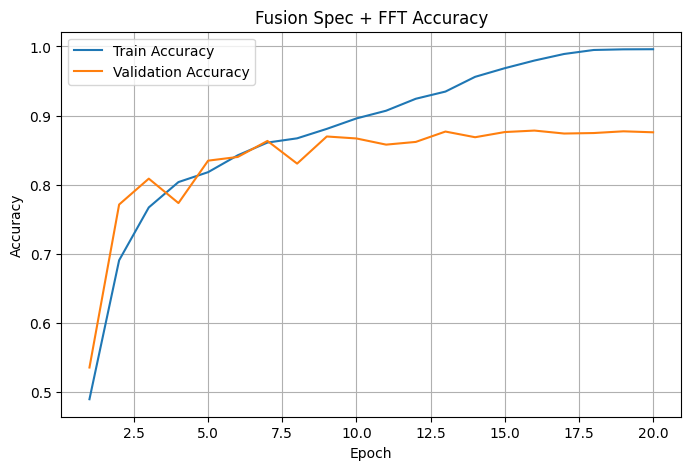

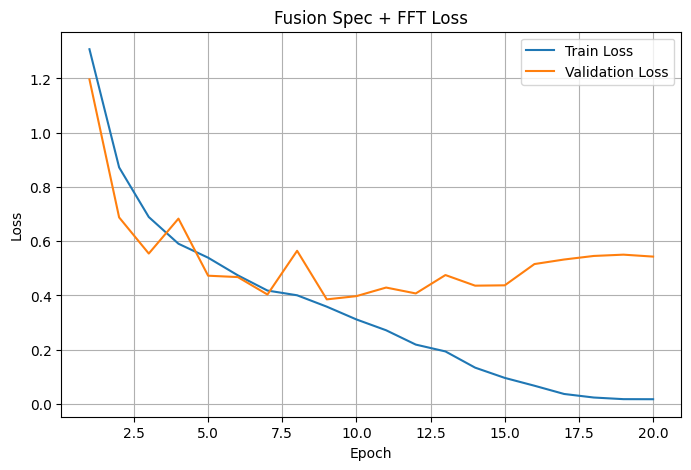

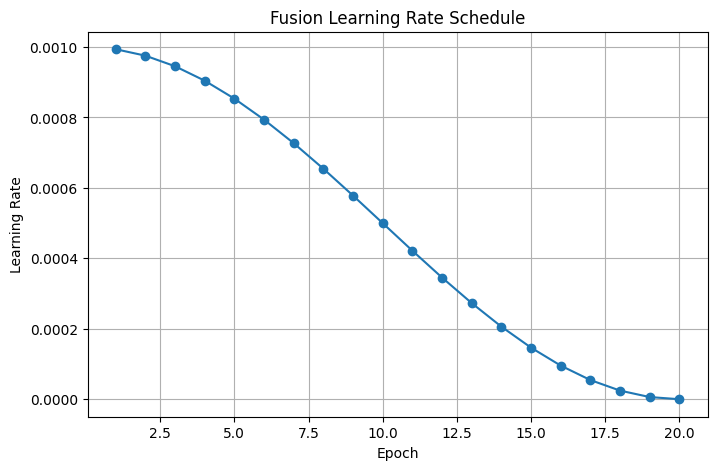

In [26]:
history_fusion_path = FUSION_SAVE_DIR / "history.csv"
history_fusion_df = pd.read_csv(history_fusion_path)
display(history_fusion_df)

plt.figure(figsize=(8, 5))
plt.plot(history_fusion_df["epoch"], history_fusion_df["train_acc"], label="Train Accuracy")
plt.plot(history_fusion_df["epoch"], history_fusion_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fusion Spec + FFT Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(FUSION_SAVE_DIR / "training_accuracy_fusion.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_fusion_df["epoch"], history_fusion_df["train_loss"], label="Train Loss")
plt.plot(history_fusion_df["epoch"], history_fusion_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fusion Spec + FFT Loss")
plt.legend()
plt.grid(True)
plt.savefig(FUSION_SAVE_DIR / "training_loss_fusion.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_fusion_df["epoch"], history_fusion_df["lr"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Fusion Learning Rate Schedule")
plt.grid(True)
plt.savefig(FUSION_SAVE_DIR / "learning_rate_fusion.png", dpi=200, bbox_inches="tight")
plt.show()

## 16.5 Evaluate fusion model

This cell reloads the best fusion checkpoint before evaluation.

Loaded best fusion model: /kaggle/working/noisy_drone_fusion_spec_fft/best.pt


Fusion Evaluation: 100%|██████████| 88/88 [00:10<00:00,  8.52it/s]


              precision    recall  f1-score   support

         DJI       0.90      0.89      0.90       400
   FutabaT14       0.89      0.85      0.87       400
    FutabaT7       0.95      0.86      0.91       400
    Graupner       0.94      0.95      0.94       400
       Noise       0.66      0.84      0.74       400
     Taranis       0.99      0.94      0.97       400
     Turnigy       0.90      0.81      0.85       400

    accuracy                           0.88      2800
   macro avg       0.89      0.88      0.88      2800
weighted avg       0.89      0.88      0.88      2800



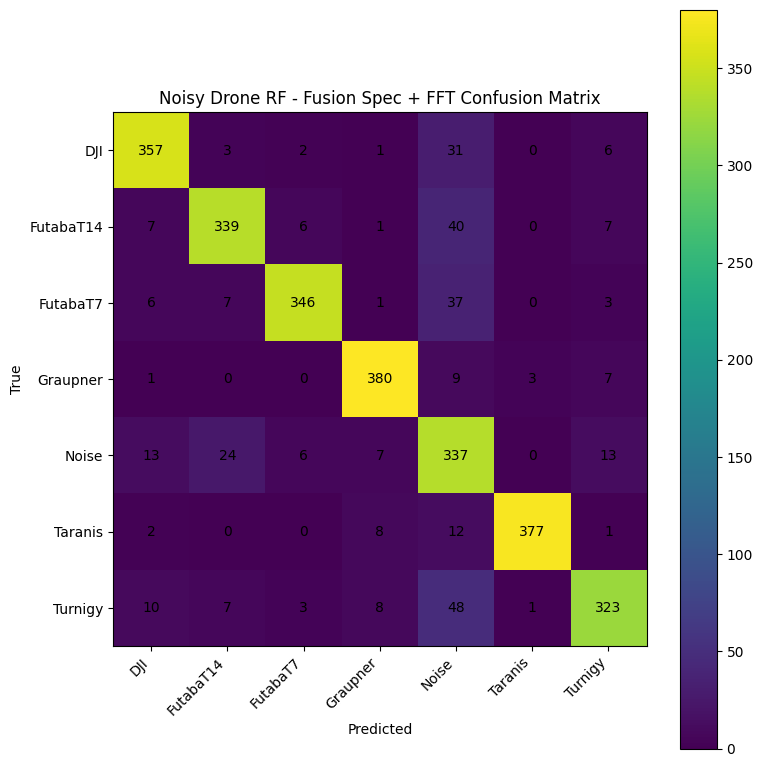

Fusion overall accuracy: 0.8782142857142857
Saved fusion confusion matrix to: /kaggle/working/noisy_drone_fusion_spec_fft/confusion_matrix_fusion.png
Saved fusion predictions to: /kaggle/working/noisy_drone_fusion_spec_fft/validation_predictions_fusion.csv


In [27]:
# Load best fusion model before evaluation.
best_fusion_path = FUSION_SAVE_DIR / "best.pt"
if best_fusion_path.exists():
    model_fusion.load_state_dict(torch.load(best_fusion_path, map_location=device))
    print("Loaded best fusion model:", best_fusion_path)
else:
    print("Best fusion checkpoint not found. Evaluating current model.")

model_fusion.eval()

all_fusion_preds = []
all_fusion_labels = []
all_fusion_snrs = []

with torch.no_grad():
    for x_spec, x_iq, labels, snrs in tqdm(valid_fusion_loader, desc="Fusion Evaluation"):
        x_spec = x_spec.to(device, non_blocking=True)
        x_iq = x_iq.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_fusion(x_spec, x_iq)
        preds = outputs.argmax(dim=1)

        all_fusion_preds.extend(preds.cpu().numpy())
        all_fusion_labels.extend(labels.cpu().numpy())
        all_fusion_snrs.extend(snrs.cpu().numpy())

print(classification_report(
    all_fusion_labels,
    all_fusion_preds,
    target_names=class_names
))

fusion_cm = confusion_matrix(all_fusion_labels, all_fusion_preds)

plt.figure(figsize=(8, 8))
plt.imshow(fusion_cm)
plt.title("Noisy Drone RF - Fusion Spec + FFT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, fusion_cm[i, j], ha="center", va="center")

plt.tight_layout()
fusion_cm_path = FUSION_SAVE_DIR / "confusion_matrix_fusion.png"
plt.savefig(fusion_cm_path, dpi=200, bbox_inches="tight")
plt.show()

results_fusion_df = pd.DataFrame({
    "label": all_fusion_labels,
    "pred": all_fusion_preds,
    "snr": all_fusion_snrs,
})
results_fusion_df["correct"] = results_fusion_df["label"] == results_fusion_df["pred"]
results_fusion_df.to_csv(FUSION_SAVE_DIR / "validation_predictions_fusion.csv", index=False)

print("Fusion overall accuracy:", results_fusion_df["correct"].mean())
print("Saved fusion confusion matrix to:", fusion_cm_path)
print("Saved fusion predictions to:", FUSION_SAVE_DIR / "validation_predictions_fusion.csv")

## 16.6 Fusion accuracy by SNR

This is the key analysis for checking whether fusion improves low-SNR classification.

,SNR,accuracy
0,-20,0.252336
1,-18,0.372340
2,-16,0.592233
3,-14,0.682540
4,-12,0.735294
5,-10,0.860465
6,-8,0.903846
7,-6,0.941176
8,-4,0.948980
9,-2,0.959016


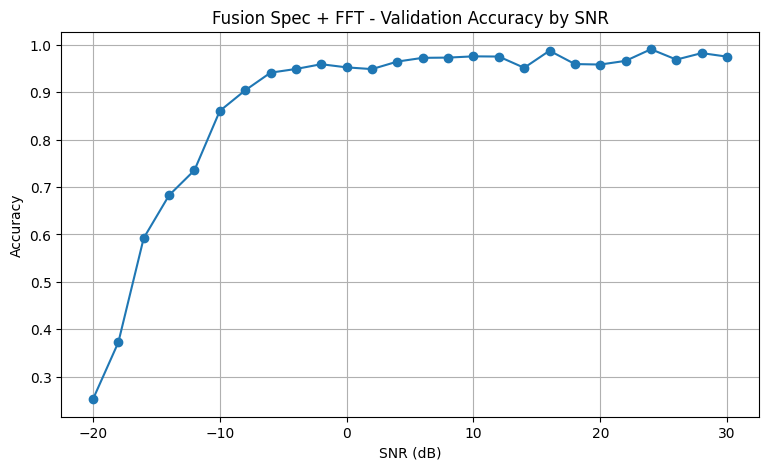

Saved SNR accuracy table to: /kaggle/working/noisy_drone_fusion_spec_fft/accuracy_by_snr_fusion.csv


In [28]:
snr_fusion_acc = results_fusion_df.groupby("snr")["correct"].mean().reset_index()
snr_fusion_acc.columns = ["SNR", "accuracy"]
display(snr_fusion_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_fusion_acc["SNR"], snr_fusion_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Fusion Spec + FFT - Validation Accuracy by SNR")
plt.grid(True)
plt.savefig(FUSION_SAVE_DIR / "accuracy_by_snr_fusion.png", dpi=200, bbox_inches="tight")
plt.show()

snr_fusion_acc.to_csv(FUSION_SAVE_DIR / "accuracy_by_snr_fusion.csv", index=False)
print("Saved SNR accuracy table to:", FUSION_SAVE_DIR / "accuracy_by_snr_fusion.csv")

## 16.7 Fusion confusion matrices by SNR group

The most important comparison is whether the fusion model improves the low-SNR group.

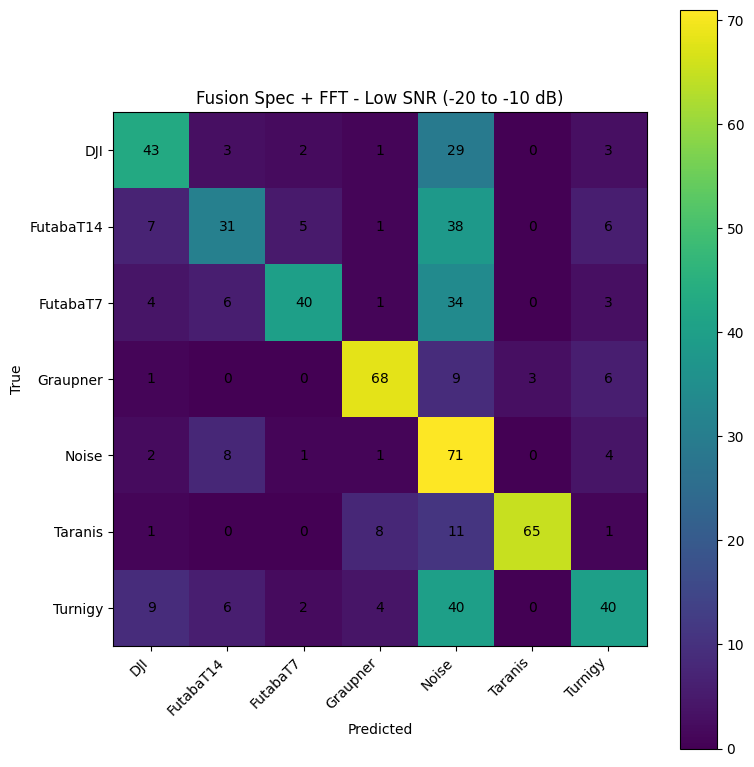

Fusion Spec + FFT - Low SNR (-20 to -10 dB)
Samples: 618
Accuracy: 0.5792880258899676


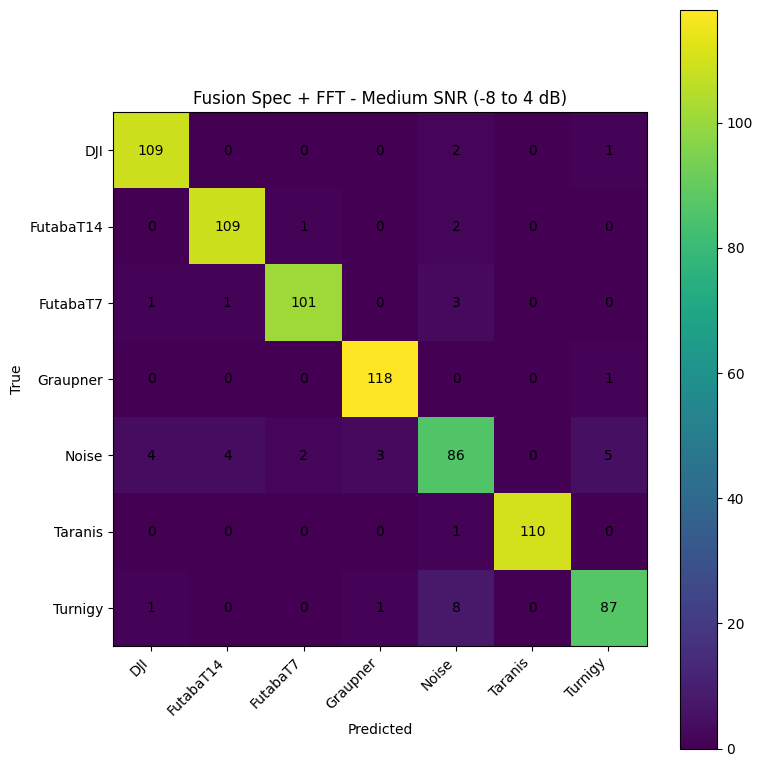

Fusion Spec + FFT - Medium SNR (-8 to 4 dB)
Samples: 761
Accuracy: 0.9461235216819974


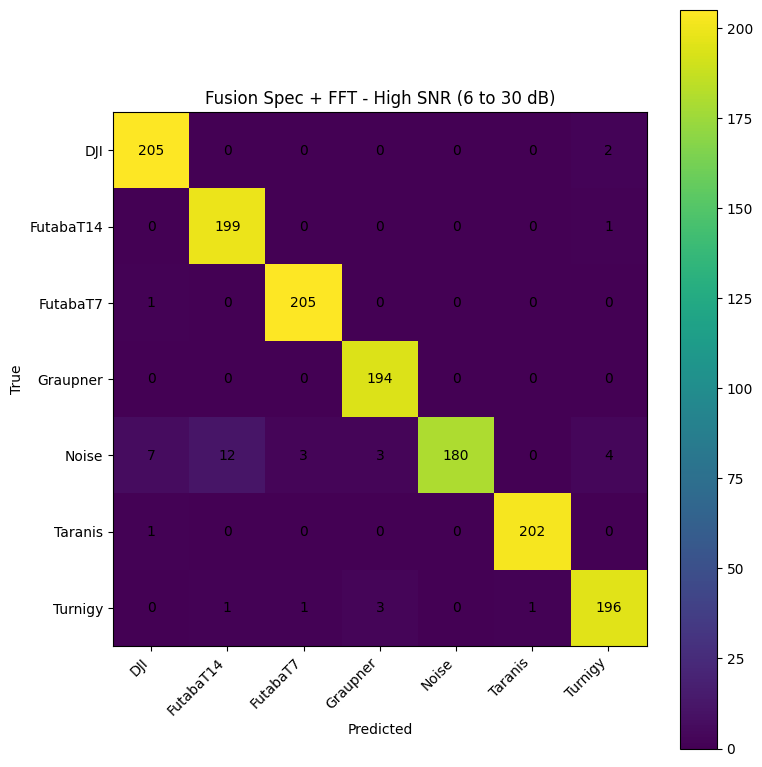

Fusion Spec + FFT - High SNR (6 to 30 dB)
Samples: 1421
Accuracy: 0.971850809289233


In [29]:
def plot_fusion_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(title)
    print("Samples:", len(df_subset))
    print("Accuracy:", df_subset["correct"].mean())

low_fusion_df = results_fusion_df[(results_fusion_df["snr"] >= -20) & (results_fusion_df["snr"] <= -10)]
medium_fusion_df = results_fusion_df[(results_fusion_df["snr"] >= -8) & (results_fusion_df["snr"] <= 4)]
high_fusion_df = results_fusion_df[(results_fusion_df["snr"] >= 6) & (results_fusion_df["snr"] <= 30)]

plot_fusion_confusion_matrix_for_subset(
    low_fusion_df,
    "Fusion Spec + FFT - Low SNR (-20 to -10 dB)",
    FUSION_SAVE_DIR / "confusion_matrix_fusion_low_snr.png"
)

plot_fusion_confusion_matrix_for_subset(
    medium_fusion_df,
    "Fusion Spec + FFT - Medium SNR (-8 to 4 dB)",
    FUSION_SAVE_DIR / "confusion_matrix_fusion_medium_snr.png"
)

plot_fusion_confusion_matrix_for_subset(
    high_fusion_df,
    "Fusion Spec + FFT - High SNR (6 to 30 dB)",
    FUSION_SAVE_DIR / "confusion_matrix_fusion_high_snr.png"
)

---

# 17. Final comparison: Spectrogram vs IQ vs Fusion

This table compares all available experiments if their prediction DataFrames exist in memory.

In [30]:
comparison_rows = []

if "results_df" in globals():
    comparison_rows.append({
        "model": "ResNet18 on x_spec",
        "overall_accuracy": results_df["correct"].mean(),
        "low_snr_accuracy": results_df[(results_df["snr"] >= -20) & (results_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_df[(results_df["snr"] >= -8) & (results_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_df[(results_df["snr"] >= 6) & (results_df["snr"] <= 30)]["correct"].mean(),
    })

if "results_iq_df" in globals():
    comparison_rows.append({
        "model": "1D CNN on x_iq",
        "overall_accuracy": results_iq_df["correct"].mean(),
        "low_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= -20) & (results_iq_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= -8) & (results_iq_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= 6) & (results_iq_df["snr"] <= 30)]["correct"].mean(),
    })

if "results_fusion_df" in globals():
    comparison_rows.append({
        "model": "Fusion x_spec + FFT(x_iq)",
        "overall_accuracy": results_fusion_df["correct"].mean(),
        "low_snr_accuracy": results_fusion_df[(results_fusion_df["snr"] >= -20) & (results_fusion_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_fusion_df[(results_fusion_df["snr"] >= -8) & (results_fusion_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_fusion_df[(results_fusion_df["snr"] >= 6) & (results_fusion_df["snr"] <= 30)]["correct"].mean(),
    })

final_comparison_df = pd.DataFrame(comparison_rows)
display(final_comparison_df)

final_comparison_path = Path("/kaggle/working/model_comparison_spec_iq_fusion.csv")
final_comparison_df.to_csv(final_comparison_path, index=False)
print("Saved final comparison table to:", final_comparison_path)

,model,overall_accuracy,low_snr_accuracy,medium_snr_accuracy,high_snr_accuracy
0,ResNet18 on x_spec,0.857500,0.540453,0.931669,0.955665
1,1D CNN on x_iq,0.740357,0.249191,0.750329,0.948628
2,Fusion x_spec + FFT(x_iq),0.878214,0.579288,0.946124,0.971851


Saved final comparison table to: /kaggle/working/model_comparison_spec_iq_fusion.csv
